<a href="https://colab.research.google.com/github/SaraJimenez-96/An-lisis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()
#regdate pasar a fecha?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()
#date pasar a fecha?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
#city (11% a revisar) y churn_date (me sirve?)
print(users.isna().sum())
print(users.isna().sum()/4000*100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
#date(1%) duration(55%) and lenght(44%)
print(usage.isna().sum())
print(usage.isna().sum()/40000*100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

## Users
- la columna `city` tiene 11% de nulos, lo cual me pide revisar un poco más a fondo lo que está pasando. En este caso revisaría si existe este mismo cliente (`user_id`) para inputar la `city`, si no dejarlo como nulo.
- la columna `churn_date` tiene 88% de nulos, lo cual me hace preguntar: ¿esta columna me sirve? ¿me dice algo? en este caso, yo la eliminaría.
## Usage
- la columna `date` 1% de nulos, lo cual podría imputar si encuentro un patrón o dejarlo como nulo.
- la columna `duration` 55% de nulos, lo cual me pide revisar, si corresponde a la duración del texto,
    en ese caso tendría sentido y lo dejaría como nulo, puesto que un texto no se mide por duración de tiempo, sino por caracteres.
- la columna `lenght` tiene 44% de nulos, lo cual me pide revisar, si corresponde a la elongación de caracteres de las llamadas,
    en ese caso tendría sentido y lo dejaría como nulo, puesto que una llamada no se mide por carácteres sino por duración.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print(users['user_id'].unique())
print(users['age'].unique())


[10000 10001 10002 ... 13997 13998 13999]
[  38   53   57   69   63   61   39   70   76   47   67   60 -999   78
   77   25   51   74   64   26   68   37   42   36   22   28   32   40
   44   49   43   79   59   46   56   58   50   54   33   24   29   45
   66   30   35   65   18   55   19   23   41   27   34   72   75   31
   71   52   20   73   21   62   48]


In [ ]:
#confirmar que tipo de sentinels puedo encontrar

sentinels = [-999, 0, -1, 1, 9999, "NA", "?", "NULL", "Unknown", "", " "]

for col in ['user_id', 'age']:
    sentinel_count = users[col].isin(sentinels).sum()
    if sentinel_count > 0:
        print(f"Columna '{col}': {sentinel_count} sentinels encontrados")
        print(f"Valores '{col}': {users[col][users[col].isin(sentinels)].unique()}")
    else:
        print(f"Columna '{col}': sin sentinels detectados")



Columna 'user_id': sin sentinels detectados
Columna 'age': 55 sentinels encontrados
Valores 'age': [-999]


- La columna `user_id` no tiene sentinels
- La columna `age` si hay sentinels, el -999 repetido 55 veces

In [ ]:
# explorar columnas numéricas de usage

print(usage['user_id'].unique())
print(usage['id'].unique())

print(usage['duration'].unique())
print(usage['length'].unique())

[10332 11458 11777 ... 10278 12723 13883]
[    1     2     3 ... 39998 39999 40000]
[ 0.09   nan  1.53 ... 22.88 31.29 21.12]
[     nan 3.90e+01 3.60e+01 4.40e+01 7.00e+01 3.10e+01 8.50e+01 4.80e+01
 2.80e+01 5.90e+01 5.00e+01 5.20e+01 6.50e+01 4.70e+01 7.20e+01 3.70e+01
 6.60e+01 5.30e+01 2.40e+01 6.40e+01 5.40e+01 1.04e+02 4.20e+01 4.90e+01
 4.50e+01 2.60e+01 4.30e+01 2.10e+01 7.40e+01 5.80e+01 8.60e+01 2.90e+01
 7.30e+01 7.80e+01 3.50e+01 4.00e+01 5.60e+01 6.70e+01 9.40e+01 4.10e+01
 3.20e+01 5.70e+01 7.00e+00 7.60e+01 5.50e+01 2.70e+01 3.40e+01 3.30e+01
 5.10e+01 6.20e+01 6.00e+01 7.10e+01 9.10e+01 1.40e+01 3.80e+01 1.50e+01
 8.70e+01 1.70e+01 1.03e+02 4.60e+01 7.50e+01 0.00e+00 8.00e+01 1.10e+01
 6.90e+01 6.80e+01 6.30e+01 6.10e+01 1.80e+01 3.00e+00 2.30e+01 2.00e+01
 9.70e+01 9.00e+00 7.70e+01 8.10e+01 1.00e+01 9.80e+01 9.60e+01 1.90e+01
 4.00e+00 8.40e+01 8.30e+01 1.01e+02 3.00e+01 1.60e+01 5.00e+00 2.20e+01
 1.20e+01 1.02e+02 9.00e+01 8.80e+01 8.00e+00 7.90e+01 8.20e+01 1.30e+0

In [ ]:
sentinels_usage = [-999, 0.0000, -1, 9999, "NA", "?", "NULL", "Unknown", "", " "]

for col in ['user_id','duration','length']:
    sentinel_count_usage = usage[col].isin(sentinels_usage).sum()
    if sentinel_count > 0:
        print(f"Columna '{col}': {sentinel_count_usage} sentinels encontrados")
        print(f"Valores '{col}': {usage[col][usage[col].isin(sentinels_usage)].unique()}")
    else:
        print(f"Columna '{col}': sin sentinels detectados")


Columna 'user_id': 0 sentinels encontrados
Valores 'user_id': []
Columna 'duration': 15 sentinels encontrados
Valores 'duration': [0.]
Columna 'length': 133 sentinels encontrados
Valores 'length': [0.]


- Las columnas `id` y `user_id` no tienen sentinels detectados
- Las columnas duration y lenght encontro 15 u 133 sentineles para 0, puedo dejarlos como error

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].unique())
print(users['plan'].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


In [ ]:
sentinels_c = ["nan", "?", "NULL", "Unknown", "", " "]

for col in ['city', 'plan']:
    sentinel_c = users[col].isin(sentinels_c).sum()
    if sentinel_c > 0:
        print(f"Columna '{col}': {sentinel_c} sentinels encontrados")
        print(f"Valores '{col}': {users[col][users[col].isin(sentinels_c)].unique()}")
    else:
        print(f"Columna '{col}': sin sentinels detectados")


Columna 'city': 96 sentinels encontrados
Valores 'city': ['?']
Columna 'plan': sin sentinels detectados


- La columna `city` tiene 96 sentinels  del tipo: ?
- La columna `plan` no tiene sentinels, ya que solo hay 2 tipos de planes

In [ ]:
# explorar columna categórica de usage
usage['type'].unique() # completa el código

array(['call', 'text'], dtype=object)

- La columna `type` no tiene sentinels, hay 2 tipos de columna con texto: call o text


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date']= pd.to_datetime(users['reg_date'],errors='coerce')
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage['date'])
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


In [ ]:
#cuantas veces está cada año en users?
print(users['reg_date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


In [ ]:
print(users[users['reg_date'].isna()])
#reviso que valores no se pudieron convertir: sale que todos se pudieron convertir.

Empty DataFrame
Columns: [user_id, first_name, last_name, age, city, reg_date, plan, churn_date]
Index: []


En `reg_date` me aparecen los años, 2022, 2023, 2024, y 2026. en este caso debo de eliminar las filas de año 2026, porque no ha sucedido aun, es un error. y debo de quitar las filas de las fechas de 2022 y 2023, dado a que no hay estos años en usage.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

[2024.   nan]


In [ ]:
#cuantas veces está cada año en usage?
print(usage['date'].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date`, tengo fechas de 2024 y un 1% que estan vacias.
Basaremos el análisis en estas fechas del 2024
Esto me dice que el df users se debe de filtrar por 2024, dado a que usage solo tiene fechas de 2024.

In [ ]:
usage['year'] = usage['date'].dt.year.astype('Int64')
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
 6   year      39950 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 2.2+ MB


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users ['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)



# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?",pd.NA)
users['city'] = users['city'].replace({np.nan: pd.NA})

# Verificar cambios
print(users['city'].isna().sum())   # cuántos valores nulos hay de tipo NA
print(users['city'].unique())       # lista de valores únicos


565
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']


In [ ]:

# Marcar fechas futuras como NA para reg_date
#loc selecciona, modifica filas y columans que sean de tipo pd.NA
users.loc[users['reg_date'].dt.year.isin([2026]), 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].unique())
print(users['reg_date'].dt.year.value_counts())
print(users['reg_date'].isna().sum())



['2022-01-01T00:00:00.000000000' '2022-01-01T06:34:17.914478619'
 '2022-01-01T13:08:35.828957239' ... '2024-12-30T10:51:24.171042768'
 '2024-12-30T17:25:42.085521392' '2024-12-31T00:00:00.000000000']
2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64
40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['missing_duration'] = usage['duration'].isna()
usage.groupby('type')['duration'].mean(). sort_values(ascending=False).head(15)
#las proporciones si dependen del type, ya que cambian mucho entre ellas, porque es la duracion de la llamada y el texto no tiene duración

type
text    120.000000
call      5.099671
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['missing_length'] = usage['length'].isna()
usage.groupby('type')['length'].mean(). sort_values(ascending=False).head(15)
#las proporciones si dependen del type, ya que cambian mucho entre ellas, porque la elongacion del texto y la llamada no tiene caracteres para contar.

type
call    1490.00000
text      51.34637
Name: length, dtype: float64

Como se puede ver, lo nulos en `duration` y `length` dependen segun el `type` porque uno los tipos cuenta el tiempo de llamada y el otro caracteres del mensaje de texto enviado. por tanto es normal que hayan nulos.Por tanto puedo dejarlos como nulos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = (
    usage
    .groupby('user_id')
    .agg(
        cant_mensajes= ('is_text','sum'),
        cant_llamadas= ('is_call','sum'),
        cant_minutos_llamada= ('duration','sum')
    )
    .reset_index()
)
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = (
    users
    .merge(
        usage_agg,
        on =['user_id'],
        how='left'
    )
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age','cant_mensajes', 'cant_llamadas','cant_minutos_llamada']
for col in columnas_numericas:
    print(col)
    print(user_profile[col].describe())
    print()


age
count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

cant_mensajes
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

cant_llamadas
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

cant_minutos_llamada
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64



In [ ]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize= True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

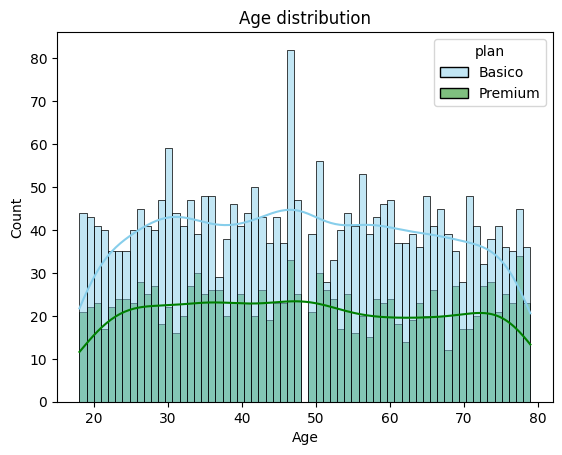

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data = user_profile,
    x= 'age',
    bins =int(np.sqrt(user_profile['age'].shape[0])),
    kde = True,
    hue='plan',
    palette=['skyblue','green']
)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


💡Insights:  En el plan Premium, por edad no hay mas de 22 personas, en promedio. En cambio, en el plan Básico, en pueden haber hasta 40 personas en promedio. En la edad de los 47 años, es donde mas cantidad de personas vemos por plan, aproximadamente 80 personas de 47 años tienen plan Básico y 32 personas tienen plan Premium
- Distribución normal acotada.

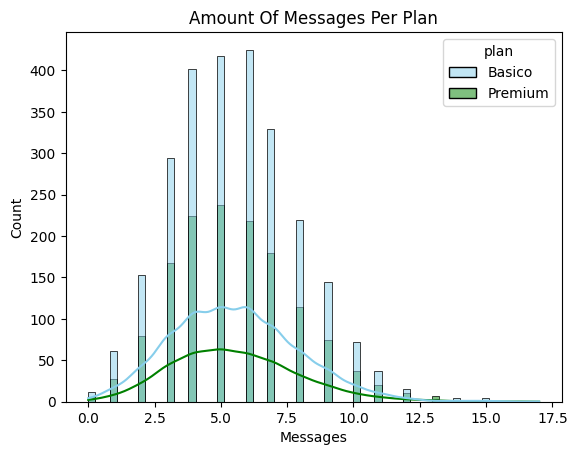

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data = user_profile,
    x= 'cant_mensajes',
    bins =int(np.sqrt(user_profile['cant_mensajes'].shape[0])),
    kde = True,
    hue='plan',
    palette=['skyblue','green']
)
plt.title('Amount Of Messages Per Plan')
plt.xlabel('Messages')
plt.ylabel('Count')
plt.show()


💡Insights: La mayoria de usuarios envia aproximadamente entre 3 y 7 mensajes. En el plan Premium, se envian menos cantidad de mensajes aproximandame 200 personas envian 5 mensajes. En cambio, en el plan Básico, se envian aproximadamente 400 personas envian 5 mensajes.
ambos planes tienenun  comportamiento similar, tienen picos en el mismo rango de mensajes entre 3 a 6 mensajes
- Distribucion: normal sesgada a la derecha, donde a mayoría envía pocos mensajes, pero unos pocos envían muchísimos.

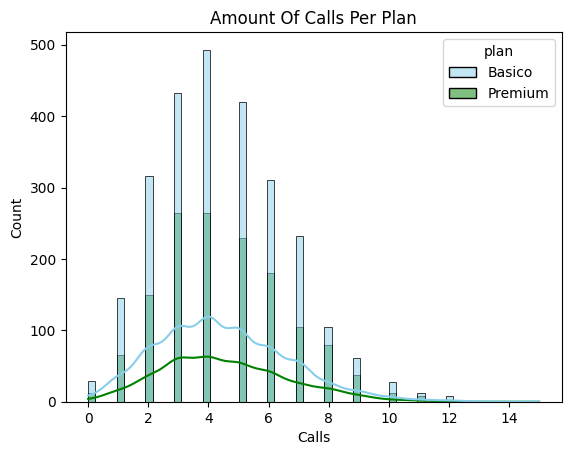

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data = user_profile,
    x= 'cant_llamadas',
    bins =int(np.sqrt(user_profile['cant_llamadas'].shape[0])),
    kde = True,
    hue='plan',
    palette=['skyblue','green']
)
plt.title('Amount Of Calls Per Plan')
plt.xlabel('Calls')
plt.ylabel('Count')
plt.show()


💡Insights: ambos planes tienen un comportamiento similar en la cantidad de llamadas, la mayoria de usuarios realiza entre 3 y 5 llamadas. Para el Plan Premium entre 250 usuarios realiza entre 3 y 4 llamadas. Por el lado del plan Básico, al redeor de 500 personas, realiza 4 llamadas
- Distribución normal sesgada a la derecha, donde a mayoría realizan pocas llamadas, pero unos pocos hacen muchas llamadas, hasta 14.

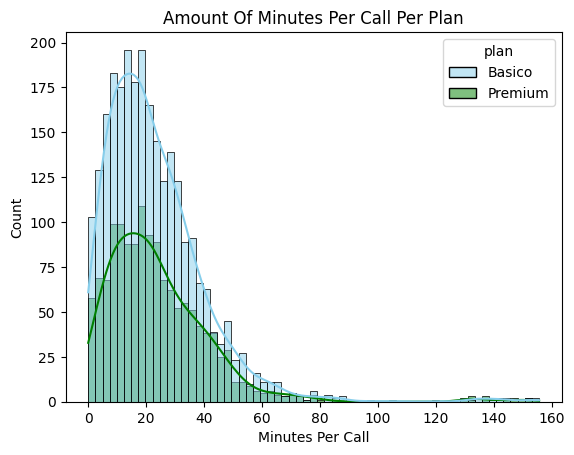

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data = user_profile,
    x= 'cant_minutos_llamada',
    bins =int(np.sqrt(user_profile['cant_minutos_llamada'].shape[0])),
    kde = True,
    hue='plan',
    palette=['skyblue','green']
)
plt.title('Amount Of Minutes Per Call Per Plan')
plt.xlabel('Minutes Per Call')
plt.ylabel('Count')
plt.show()

💡Insights: Ambos planes tienen un comportamiento similar, en primedio se realizan llamadas de 18-19 minutos. aproximadamente 90 personas realizan llamadasde 14-18 minutos. Por otro lado, en el Plan Básico, al rededor de 190 personas realizan llamadas de 18-19 minutos
- Distribución sesgada a la derecha, donde a mayoría usan pocos minutos por llamada, pero unos pocos hacen llamadas largas o de muchos minutos, hasta 155minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

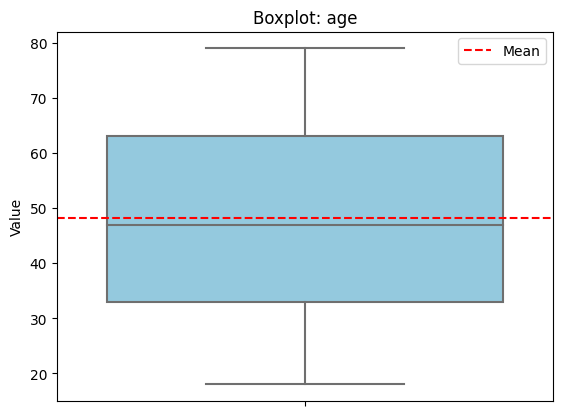

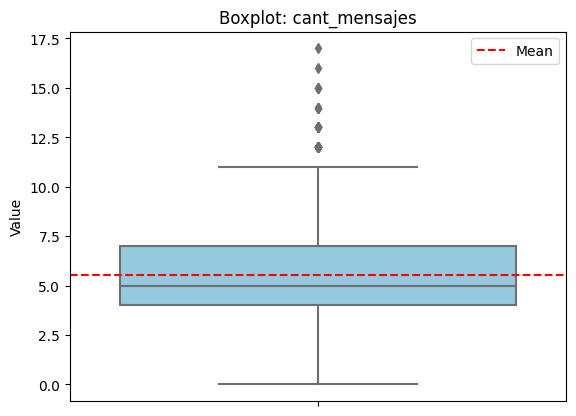

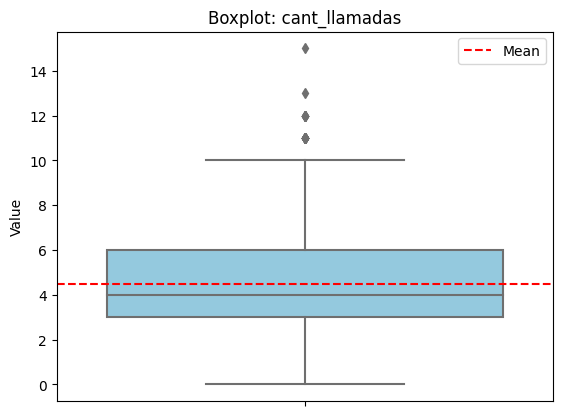

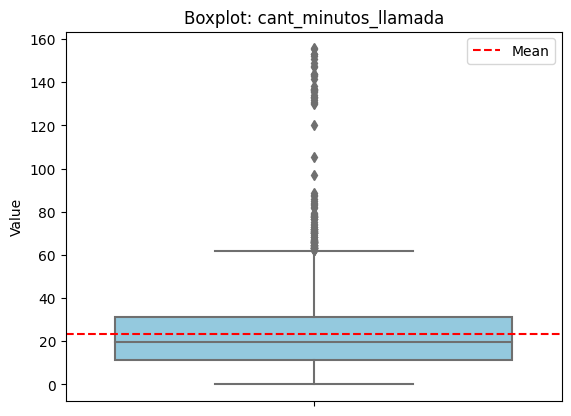

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, y=col, color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.axhline(user_profile[col].mean(), color="red", linestyle="--", label="Mean")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta pocos ouliers
- cant_llamadas: presenta pocos outliers
- cant_minutos_llamada: presenta muchos outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    q1= user_profile[col].quantile(0.25)
    q3= user_profile[col].quantile(0.75)
    IQR = q3-q1
    umbral_sup = q3 +1.5*IQR
    outliers = user_profile.query(f"{col} > @umbral_sup")
    print(f"Outliers en {col}:")
    print(outliers[[col]].value_counts())


Outliers en cant_mensajes:
cant_mensajes
12.0             25
13.0             10
14.0              5
15.0              4
16.0              1
17.0              1
dtype: int64
Outliers en cant_llamadas:
cant_llamadas
11.0             20
12.0              8
13.0              1
15.0              1
dtype: int64
Outliers en cant_minutos_llamada:
cant_minutos_llamada
68.16                   2
63.05                   2
62.11                   1
83.72                   1
129.75                  1
                       ..
68.04                   1
67.32                   1
67.11                   1
66.81                   1
155.69                  1
Length: 107, dtype: int64


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:  Se envian en promedio 5.5 mensajes. para las llamadas, hay en promedio 4.5 llamadas y para los minutos por llamdas esta en promedio 23 minutos.
- cant_mensajes: aunque los outliers entre 15 y 17 mensajes son altos, pero no absurdos, yo los mantendria.
- cant_llamadas: aunque los outliers entre 12 y 15 llamadas son altas y mas escasas, pero no absurdas; yo los mantendria.
- cant_minutos_llamada: la mayoria de los usuarios mantiene llamadas entre 11 y 31 minutos, es decir que tener un outlier de mas de 100 minutos, es bastante claro que es un outlier, y al ser de pocas repeticiones (1 vez), podria  eliminar dichos outliers

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def grupo_uso_classify(row):
    if row ['cant_llamadas']<5 and row['cant_mensajes']<5:
        return 'Bajo Uso'
    elif row ['cant_llamadas']<10 and row['cant_mensajes']<10:
        return 'Uso Medio'
    else:
        return 'Alto Uso'
user_profile['grupo_uso'] =user_profile.apply(grupo_uso_classify, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto Uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso Medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def grupo_edad_classify(row):
    if row ['age']<30:
        return 'Joven'
    elif row ['age']<60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] =user_profile.apply(grupo_edad_classify, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:

user_profile['grupo_uso'].value_counts(normalize= True)
#porcentages por grupo de uso. 73.5% le da un udo medio


Uso Medio    0.73575
Bajo Uso     0.19450
Alto Uso     0.06975
Name: grupo_uso, dtype: float64

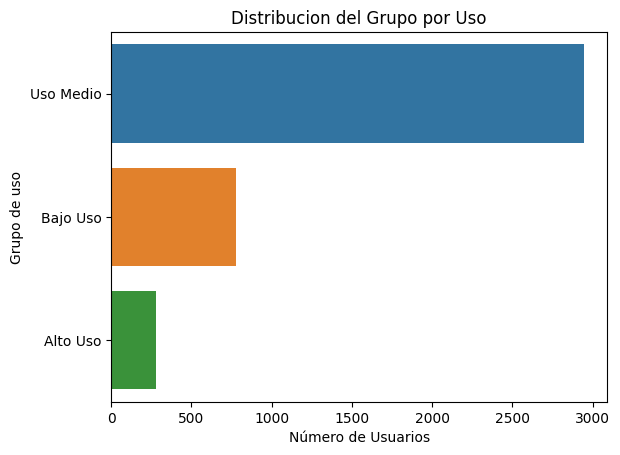

In [ ]:
# Visualización de los segmentos por uso
user_profile['grupo_uso'].value_counts(normalize= True)
sns.countplot(data=user_profile, y ='grupo_uso', order =user_profile['grupo_uso'].value_counts().index)
plt.title('Distribucion del Grupo por Uso')
plt.xlabel('Número de Usuarios')
plt.ylabel('Grupo de uso')
plt.show()
# se encuentran mas cantidad de llamadas y mensajes del grupo medio o de mas de 10 de cada una de las categorias

In [ ]:
user_profile['grupo_edad'].value_counts(normalize= True)
#porcentages por grupo de edades. 50.5% son adultos


Adulto          0.5045
Adulto Mayor    0.3055
Joven           0.1900
Name: grupo_edad, dtype: float64

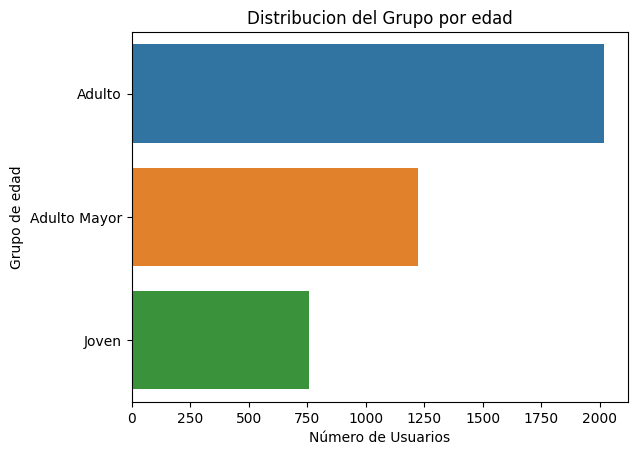

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, y ='grupo_edad')
plt.title('Distribucion del Grupo por edad')
plt.xlabel('Número de Usuarios')
plt.ylabel('Grupo de edad')
plt.show()
